In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score
from sklearn.metrics import silhouette_score

In [2]:
df = pd.read_csv("data.csv", sep=";")
df

,id,region,fed_okr,tipnp,Q1,Q2,Q3,Q4,Q5,Q6,Q7,AGE,EDU,GENDER,PROF,INCOME
0,1,66,6,6,0,1,1,4,4,4,4,57,3,2,1,6
1,2,24,7,2,0,1,2,3,3,5,3,58,3,2,1,8
2,3,33,1,4,0,1,2,3,3,4,4,56,5,2,1,8
3,4,37,1,4,1,1,2,4,4,4,2,63,3,2,1,7
4,5,39,2,4,1,1,4,4,4,5,4,64,2,1,1,7
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
495,496,66,6,5,3,0,1,4,4,7,7,25,3,1,99,7
496,497,25,8,7,3,0,4,4,4,97,2,35,2,2,99,5
497,498,74,6,3,0,2,4,4,4,97,3,49,3,1,99,6
498,499,74,6,3,2,2,1,2,2,5,5,33,2,1,99,8


# 1. При помощи кластерного анализа классифицируйте респондентов на типичные группы по особенностям проведения отпуска.

In [3]:
x = df[["Q1", "Q2", "AGE"]]
y = df[["Q6", "Q7"]].values

scaler = StandardScaler()
x_scaler = scaler.fit_transform(x)

In [4]:
data_Kmeans = {
	"lloyd": [],
	"elkan": []
}

data_silhouette = {
	"lloyd": [],
	"elkan": []	
}

k_range = range(2, 16)

for k in k_range:
	for algorithm in ["lloyd", "elkan"]:
		model_KMeans = KMeans(k, algorithm=algorithm, random_state=42)
		model_KMeans.fit(x_scaler)

		data_Kmeans[algorithm] += [model_KMeans.inertia_]
		data_silhouette[algorithm] += [silhouette_score(x_scaler, model_KMeans.labels_)]

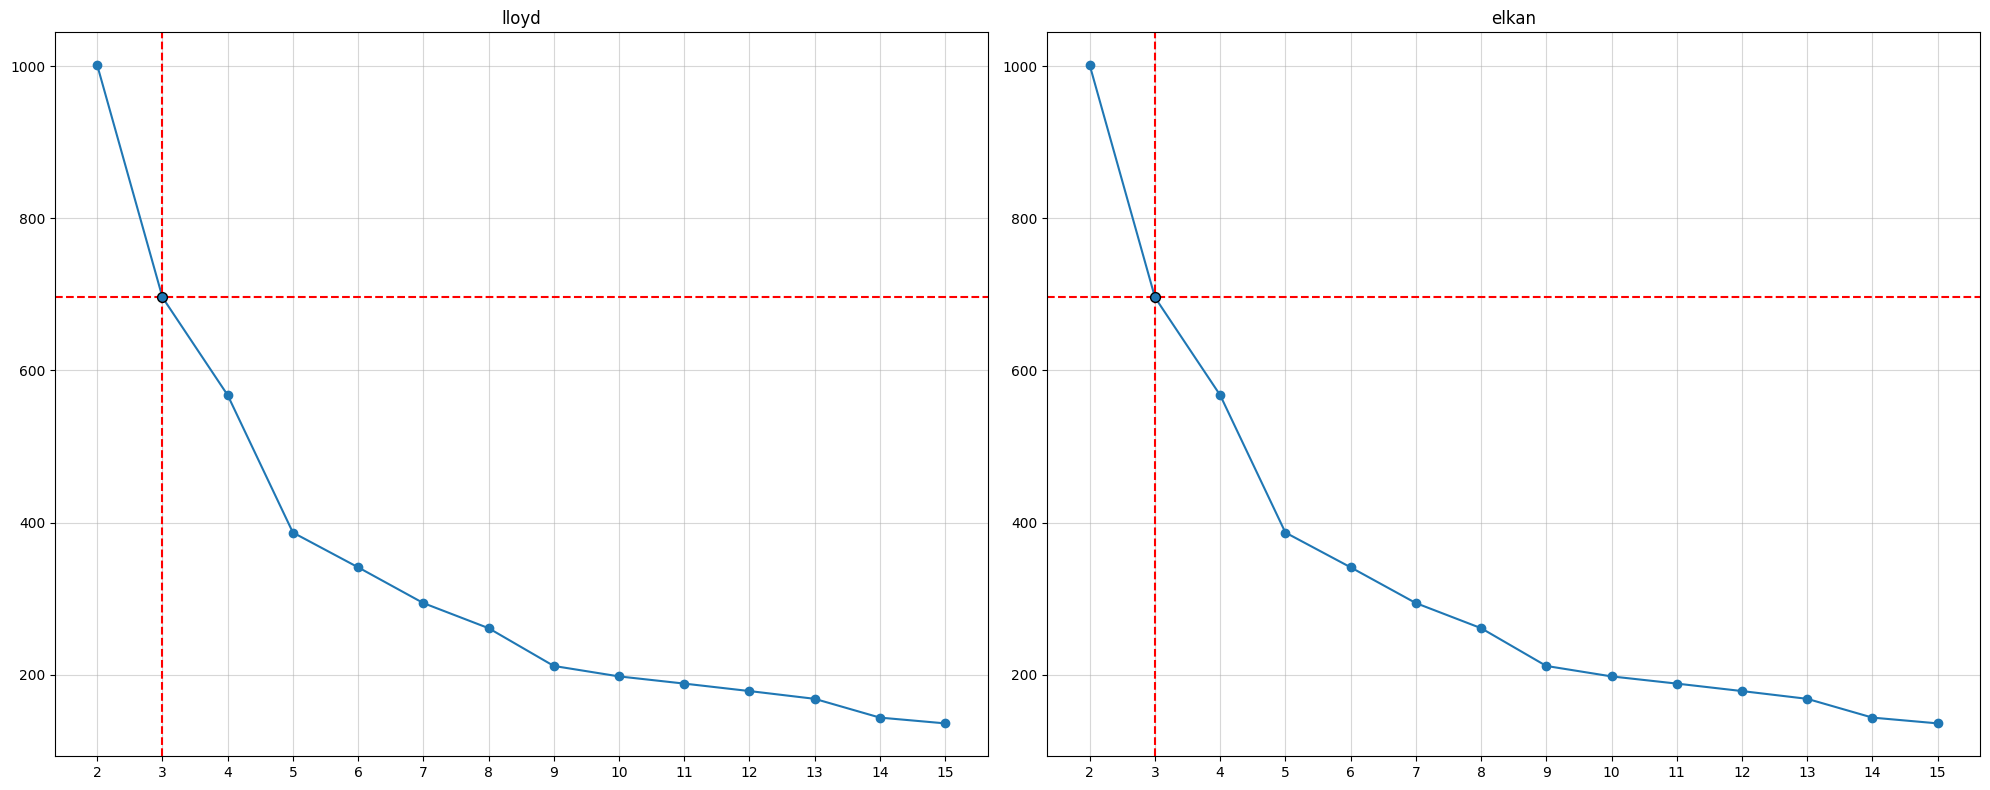

In [5]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

for i, (k, v) in enumerate(data_Kmeans.items()):
	best_index_score = np.argmin(np.diff(v)) + 1
	best_score = v[best_index_score]
	best_k_Kmeans = k_range[best_index_score]	

	ax[i].plot(k_range, v, "o-")
	ax[i].axhline(best_score, c="r", ls="--")
	ax[i].axvline(best_k_Kmeans, c="r", ls="--")
	ax[i].scatter(best_k_Kmeans, best_score, s=50, ec="k", zorder=3)
	ax[i].grid(alpha=.5)
	
	ax[i].set_xticks(k_range)
	ax[i].set_title(k)

plt.tight_layout()
plt.show()

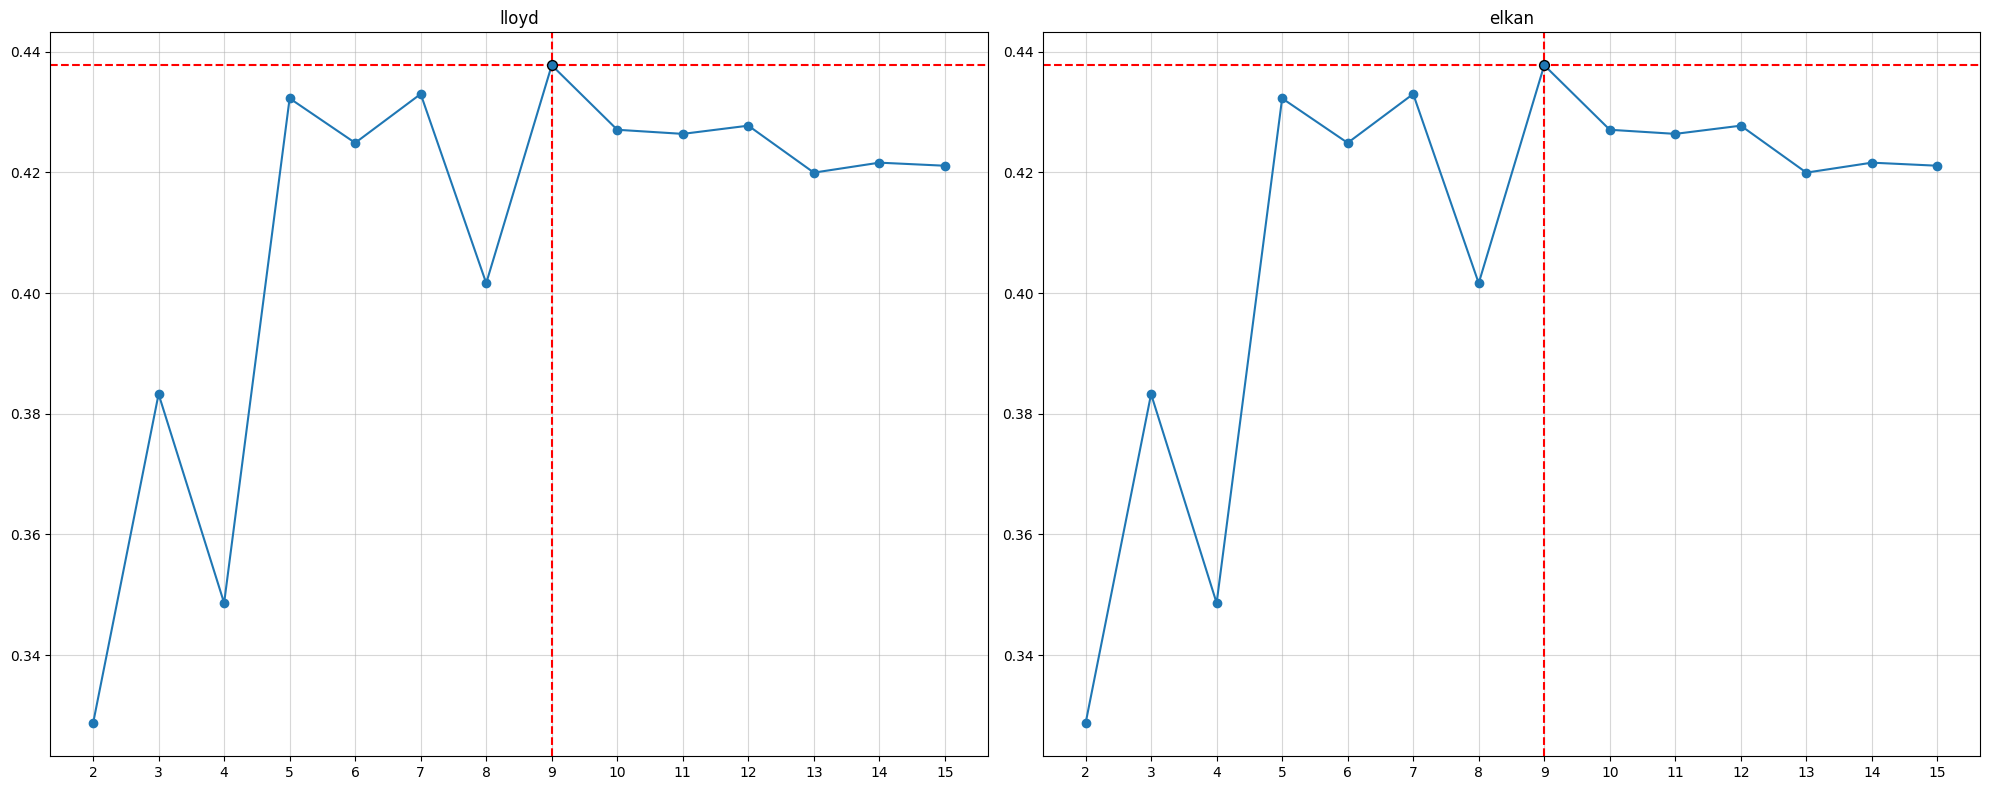

In [6]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

for i, (k, v) in enumerate(data_silhouette.items()):
	best_index_score = np.argmax(v)
	best_score = v[best_index_score]
	best_k_silhouette = k_range[best_index_score]

	ax[i].plot(k_range, v, "o-")
	ax[i].axhline(best_score, c="r", ls="--")
	ax[i].axvline(best_k_silhouette, c="r", ls="--")
	ax[i].scatter(best_k_silhouette, best_score, s=50, ec="k", zorder=3)
	ax[i].grid(alpha=.5)
	
	ax[i].set_xticks(k_range)
	ax[i].set_title(k)

plt.tight_layout()
plt.show()

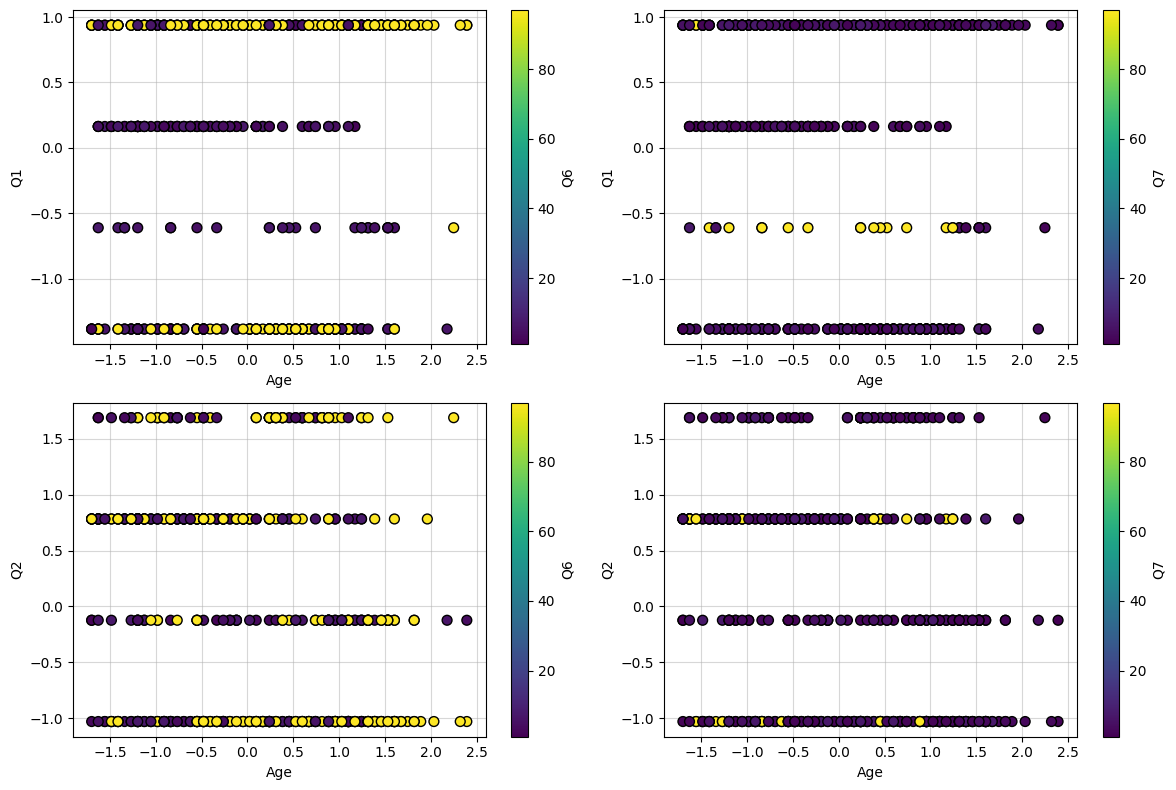

In [7]:
fit, ax = plt.subplots(2, 2, figsize=(12, 8))

sc1 = ax[0][0].scatter(x_scaler[:, 2], x_scaler[:, 0], c=y[:, 0], s=50, ec="k", zorder=3)
sc2 = ax[0][1].scatter(x_scaler[:, 2], x_scaler[:, 0], c=y[:, 1], s=50, ec="k", zorder=3)
sc3 = ax[1][0].scatter(x_scaler[:, 2], x_scaler[:, 1], c=y[:, 0], s=50, ec="k", zorder=3)
sc4 = ax[1][1].scatter(x_scaler[:, 2], x_scaler[:, 1], c=y[:, 1], s=50, ec="k", zorder=3)

plt.colorbar(sc1, ax=ax[0][0]).set_label("Q6")
plt.colorbar(sc2, ax=ax[0][1]).set_label("Q7")
plt.colorbar(sc3, ax=ax[1][0]).set_label("Q6")
plt.colorbar(sc4, ax=ax[1][1]).set_label("Q7")

ax[0][0].set_xlabel("Age")
ax[0][0].set_ylabel("Q1")
ax[0][1].set_xlabel("Age")
ax[0][1].set_ylabel("Q1")
ax[1][0].set_xlabel("Age")
ax[1][0].set_ylabel("Q2")
ax[1][1].set_xlabel("Age")
ax[1][1].set_ylabel("Q2")

ax[0][0].grid(alpha=.5)
ax[0][1].grid(alpha=.5)
ax[1][0].grid(alpha=.5)
ax[1][1].grid(alpha=.5)

plt.tight_layout()
plt.show()

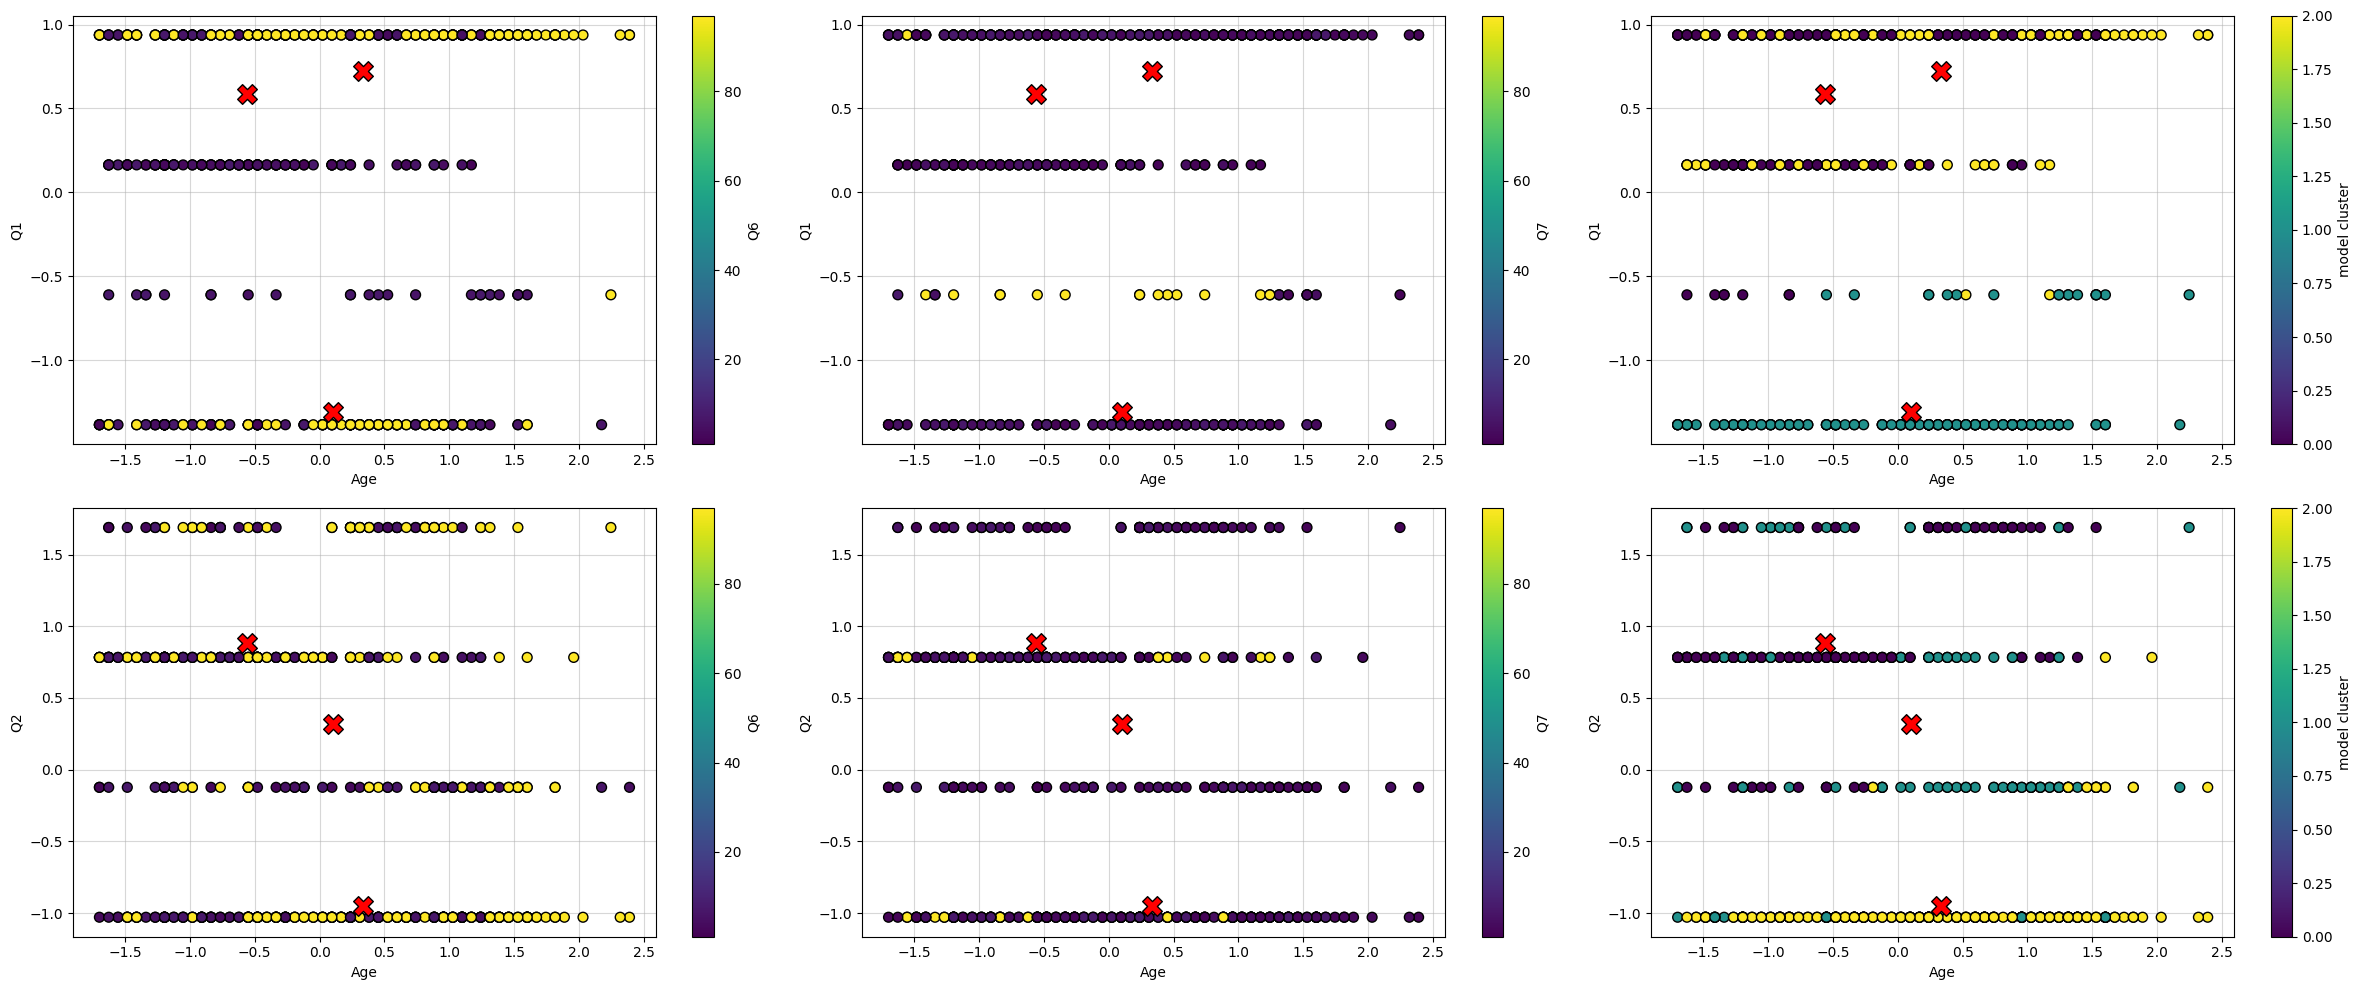

In [8]:
model_KMeans = KMeans(3, random_state=42)
model_KMeans.fit(x_scaler)

fit, ax = plt.subplots(2, 3, figsize=(24, 10))

sc10 = ax[0][0].scatter(x_scaler[:, 2], x_scaler[:, 0], c=y[:, 0], s=50, ec="k", zorder=3)
ax[0][0].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 0], c="r", marker="X", ec="k", s=200, zorder=3)

sc11 = ax[0][1].scatter(x_scaler[:, 2], x_scaler[:, 0], c=y[:, 1], s=50, ec="k", zorder=3)
ax[0][1].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 0], c="r", marker="X", ec="k", s=200, zorder=3)

sc12 = ax[0][2].scatter(x_scaler[:, 2], x_scaler[:, 0], c=model_KMeans.labels_, s=50, ec="k", zorder=3)
ax[0][2].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 0], c="r", marker="X", ec="k", s=200, zorder=3)

sc20 = ax[1][0].scatter(x_scaler[:, 2], x_scaler[:, 1], c=y[:, 0], s=50, ec="k", zorder=3)
ax[1][0].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=200, zorder=3)

sc21 = ax[1][1].scatter(x_scaler[:, 2], x_scaler[:, 1], c=y[:, 1], s=50, ec="k", zorder=3)
ax[1][1].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=200, zorder=3)

sc22 = ax[1][2].scatter(x_scaler[:, 2], x_scaler[:, 1], c=model_KMeans.labels_, s=50, ec="k", zorder=3)
ax[1][2].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=200, zorder=3)

plt.colorbar(sc10, ax=ax[0][0]).set_label("Q6")
plt.colorbar(sc11, ax=ax[0][1]).set_label("Q7")
plt.colorbar(sc12, ax=ax[0][2]).set_label("model cluster")
plt.colorbar(sc20, ax=ax[1][0]).set_label("Q6")
plt.colorbar(sc21, ax=ax[1][1]).set_label("Q7")
plt.colorbar(sc22, ax=ax[1][2]).set_label("model cluster")

ax[0][0].set_xlabel("Age")
ax[0][0].set_ylabel("Q1")
ax[0][1].set_xlabel("Age")
ax[0][1].set_ylabel("Q1")
ax[1][0].set_xlabel("Age")
ax[1][0].set_ylabel("Q2")
ax[1][1].set_xlabel("Age")
ax[1][1].set_ylabel("Q2")
ax[0][2].set_xlabel("Age")
ax[0][2].set_ylabel("Q1")
ax[1][2].set_xlabel("Age")
ax[1][2].set_ylabel("Q2")

ax[0][0].grid(alpha=.5)
ax[0][1].grid(alpha=.5)
ax[1][0].grid(alpha=.5)
ax[1][1].grid(alpha=.5)
ax[0][2].grid(alpha=.5)
ax[0][2].grid(alpha=.5)
ax[1][2].grid(alpha=.5)
ax[1][2].grid(alpha=.5)



	
plt.tight_layout()
plt.show()

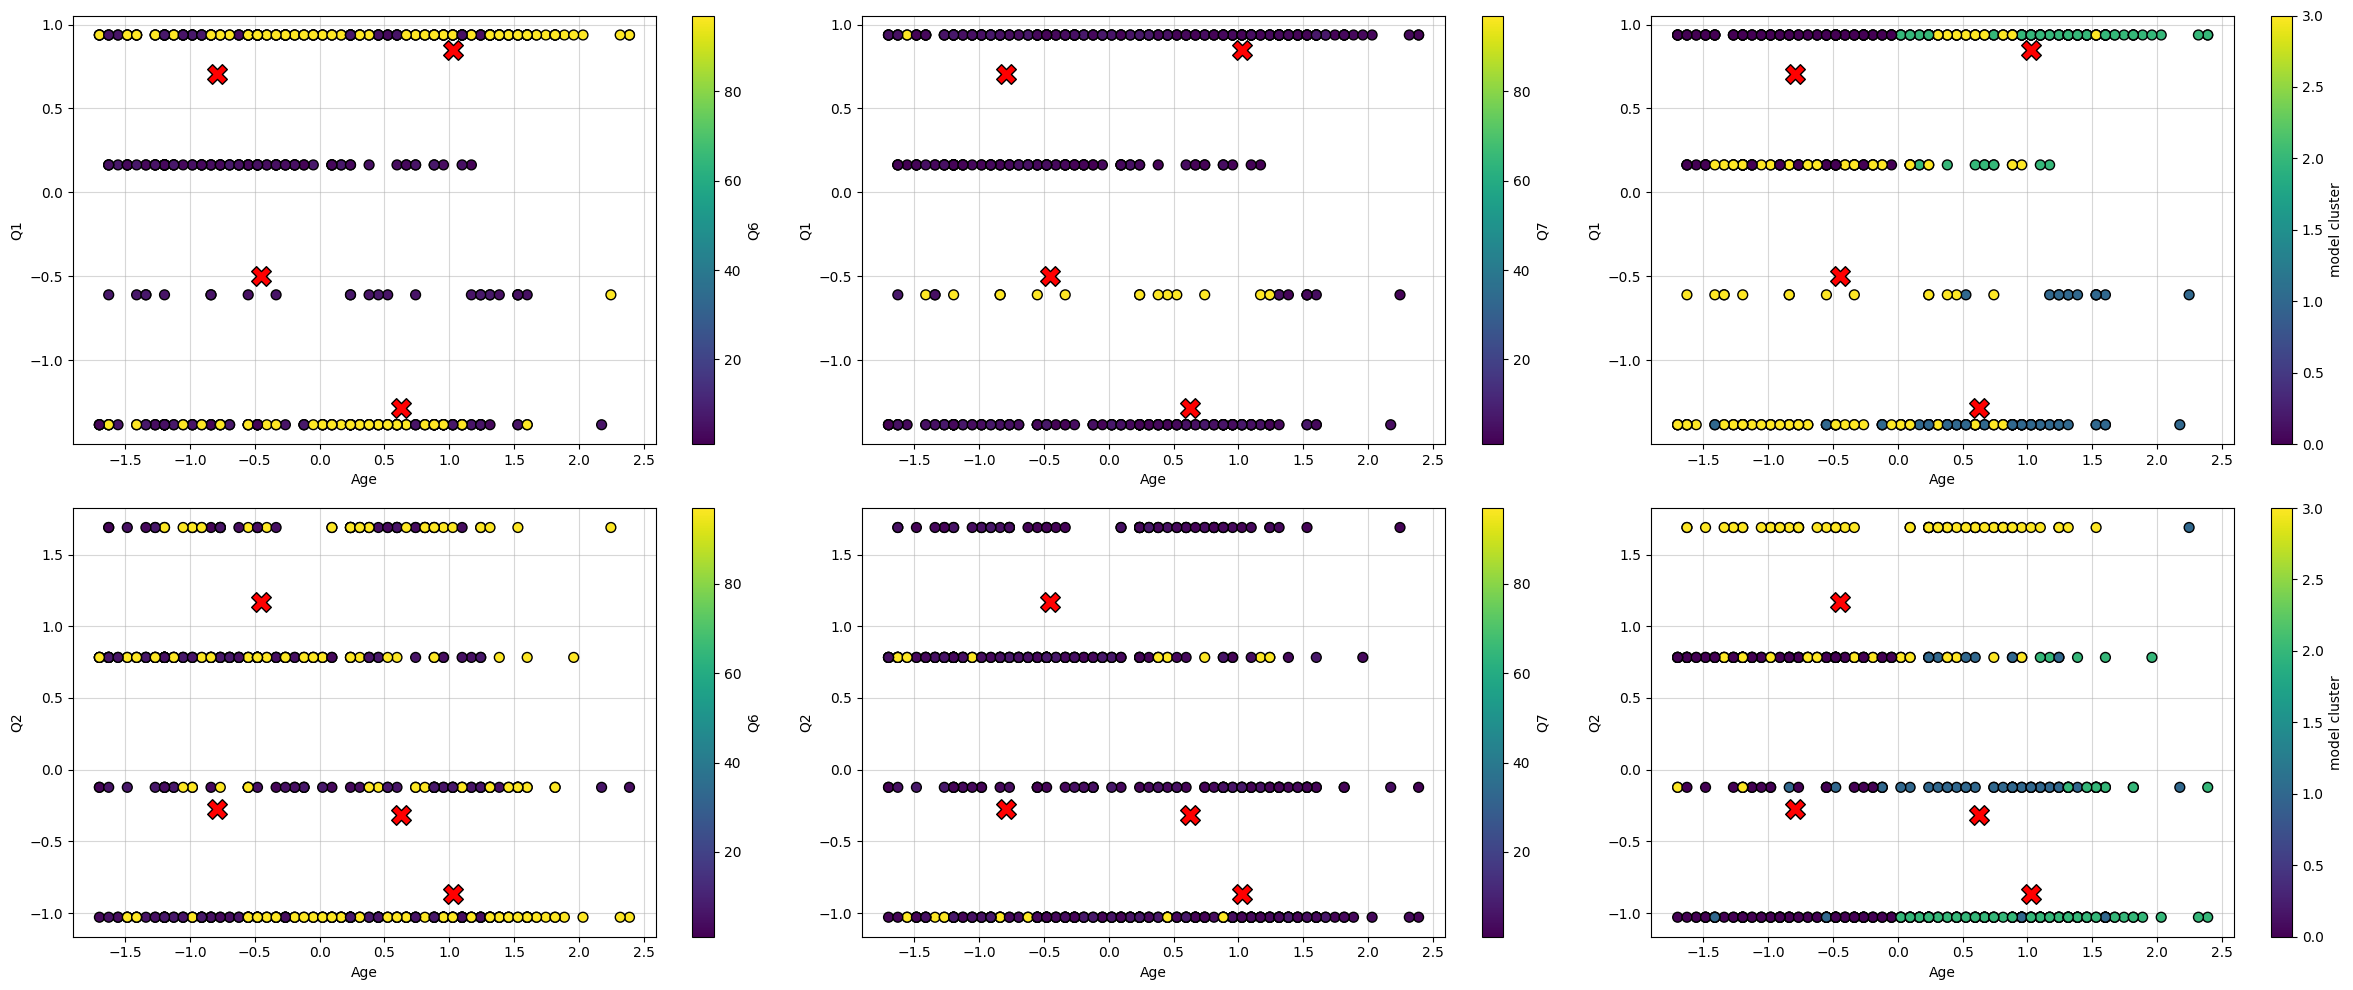

In [9]:
model_KMeans = KMeans(4, random_state=42)
model_KMeans.fit(x_scaler)

fit, ax = plt.subplots(2, 3, figsize=(24, 10))

sc10 = ax[0][0].scatter(x_scaler[:, 2], x_scaler[:, 0], c=y[:, 0], s=50, ec="k", zorder=3)
ax[0][0].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 0], c="r", marker="X", ec="k", s=200, zorder=3)

sc11 = ax[0][1].scatter(x_scaler[:, 2], x_scaler[:, 0], c=y[:, 1], s=50, ec="k", zorder=3)
ax[0][1].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 0], c="r", marker="X", ec="k", s=200, zorder=3)

sc12 = ax[0][2].scatter(x_scaler[:, 2], x_scaler[:, 0], c=model_KMeans.labels_, s=50, ec="k", zorder=3)
ax[0][2].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 0], c="r", marker="X", ec="k", s=200, zorder=3)

sc20 = ax[1][0].scatter(x_scaler[:, 2], x_scaler[:, 1], c=y[:, 0], s=50, ec="k", zorder=3)
ax[1][0].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=200, zorder=3)

sc21 = ax[1][1].scatter(x_scaler[:, 2], x_scaler[:, 1], c=y[:, 1], s=50, ec="k", zorder=3)
ax[1][1].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=200, zorder=3)

sc22 = ax[1][2].scatter(x_scaler[:, 2], x_scaler[:, 1], c=model_KMeans.labels_, s=50, ec="k", zorder=3)
ax[1][2].scatter(model_KMeans.cluster_centers_[:, 2], model_KMeans.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=200, zorder=3)

plt.colorbar(sc10, ax=ax[0][0]).set_label("Q6")
plt.colorbar(sc11, ax=ax[0][1]).set_label("Q7")
plt.colorbar(sc12, ax=ax[0][2]).set_label("model cluster")
plt.colorbar(sc20, ax=ax[1][0]).set_label("Q6")
plt.colorbar(sc21, ax=ax[1][1]).set_label("Q7")
plt.colorbar(sc22, ax=ax[1][2]).set_label("model cluster")

ax[0][0].set_xlabel("Age")
ax[0][0].set_ylabel("Q1")
ax[0][1].set_xlabel("Age")
ax[0][1].set_ylabel("Q1")
ax[1][0].set_xlabel("Age")
ax[1][0].set_ylabel("Q2")
ax[1][1].set_xlabel("Age")
ax[1][1].set_ylabel("Q2")
ax[0][2].set_xlabel("Age")
ax[0][2].set_ylabel("Q1")
ax[1][2].set_xlabel("Age")
ax[1][2].set_ylabel("Q2")

ax[0][0].grid(alpha=.5)
ax[0][1].grid(alpha=.5)
ax[1][0].grid(alpha=.5)
ax[1][1].grid(alpha=.5)
ax[0][2].grid(alpha=.5)
ax[0][2].grid(alpha=.5)
ax[1][2].grid(alpha=.5)
ax[1][2].grid(alpha=.5)

	
plt.tight_layout()
plt.show()

# 2. При помощи кластерного анализа классифицируйте респондентов на группы по планируемой сумме расходов на отпуск.

In [10]:
x = df[["Q6", "Q7", "AGE", "EDU", "INCOME"]]

scaler = StandardScaler()
x_scaler = scaler.fit_transform(x)

In [11]:
data_Kmeans = {
	"lloyd": [],
	"elkan": []
}

data_silhouette = {
	"lloyd": [],
	"elkan": []	
}

k_range = range(2, 16)

for k in k_range:
	for algorithm in ["lloyd", "elkan"]:
		model_KMeans = KMeans(k, algorithm=algorithm, random_state=42)
		model_KMeans.fit(x_scaler)

		data_Kmeans[algorithm] += [model_KMeans.inertia_]
		data_silhouette[algorithm] += [silhouette_score(x_scaler, model_KMeans.labels_)]

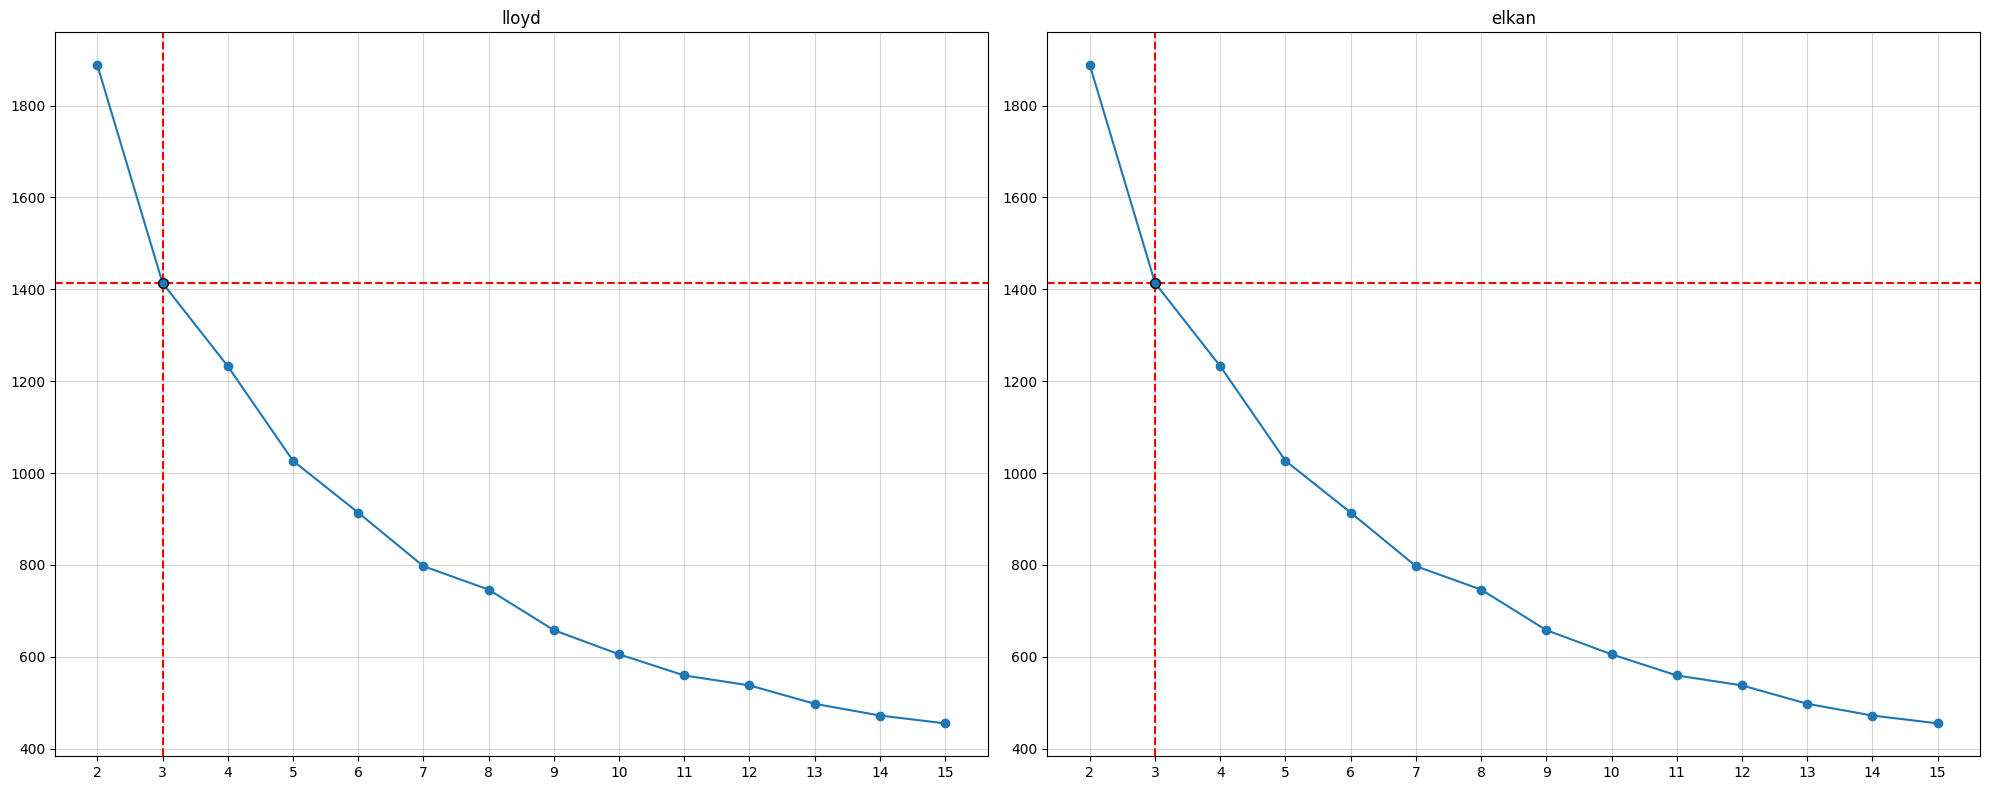

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

for i, (k, v) in enumerate(data_Kmeans.items()):
	best_index_score = np.argmin(np.diff(v)) + 1
	best_score = v[best_index_score]
	best_k_Kmeans = k_range[best_index_score]	

	ax[i].plot(k_range, v, "o-")
	ax[i].axhline(best_score, c="r", ls="--")
	ax[i].axvline(best_k_Kmeans, c="r", ls="--")
	ax[i].scatter(best_k_Kmeans, best_score, s=50, ec="k", zorder=3)
	ax[i].grid(alpha=.5)
	
	ax[i].set_xticks(k_range)
	ax[i].set_title(k)

plt.tight_layout()
plt.show()

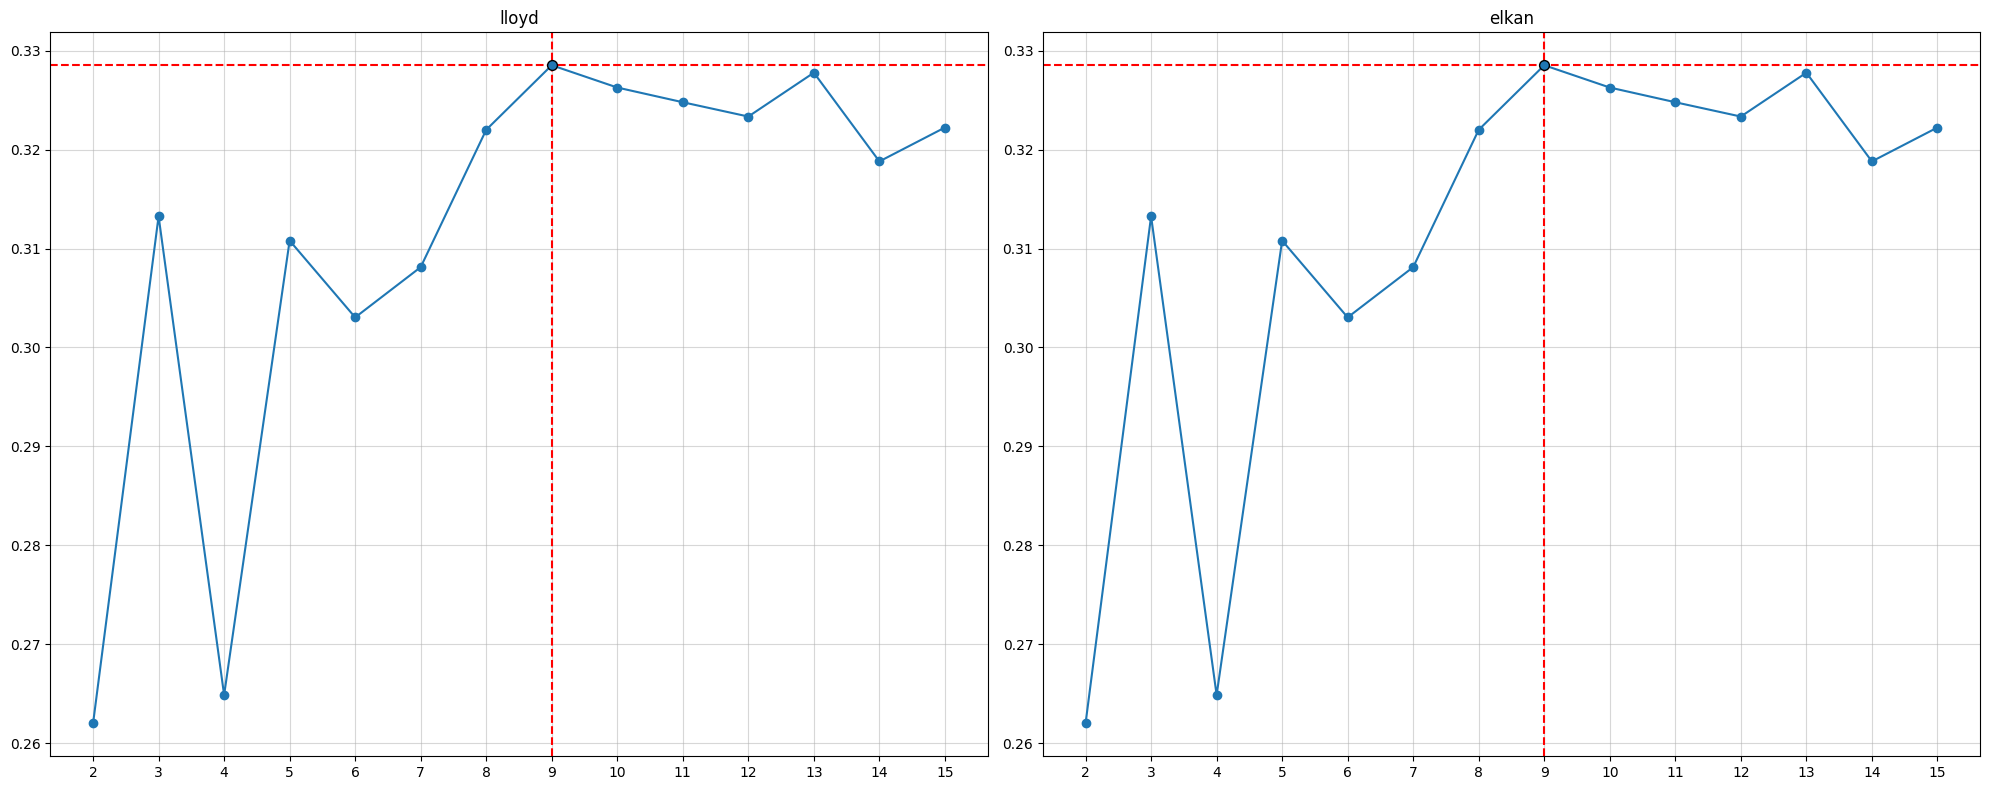

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(20, 8))

for i, (k, v) in enumerate(data_silhouette.items()):
	best_index_score = np.argmax(v)
	best_score = v[best_index_score]
	best_k_silhouette = k_range[best_index_score]

	ax[i].plot(k_range, v, "o-")
	ax[i].axhline(best_score, c="r", ls="--")
	ax[i].axvline(best_k_silhouette, c="r", ls="--")
	ax[i].scatter(best_k_silhouette, best_score, s=50, ec="k", zorder=3)
	ax[i].grid(alpha=.5)
	
	ax[i].set_xticks(k_range)
	ax[i].set_title(k)

plt.tight_layout()
plt.show()

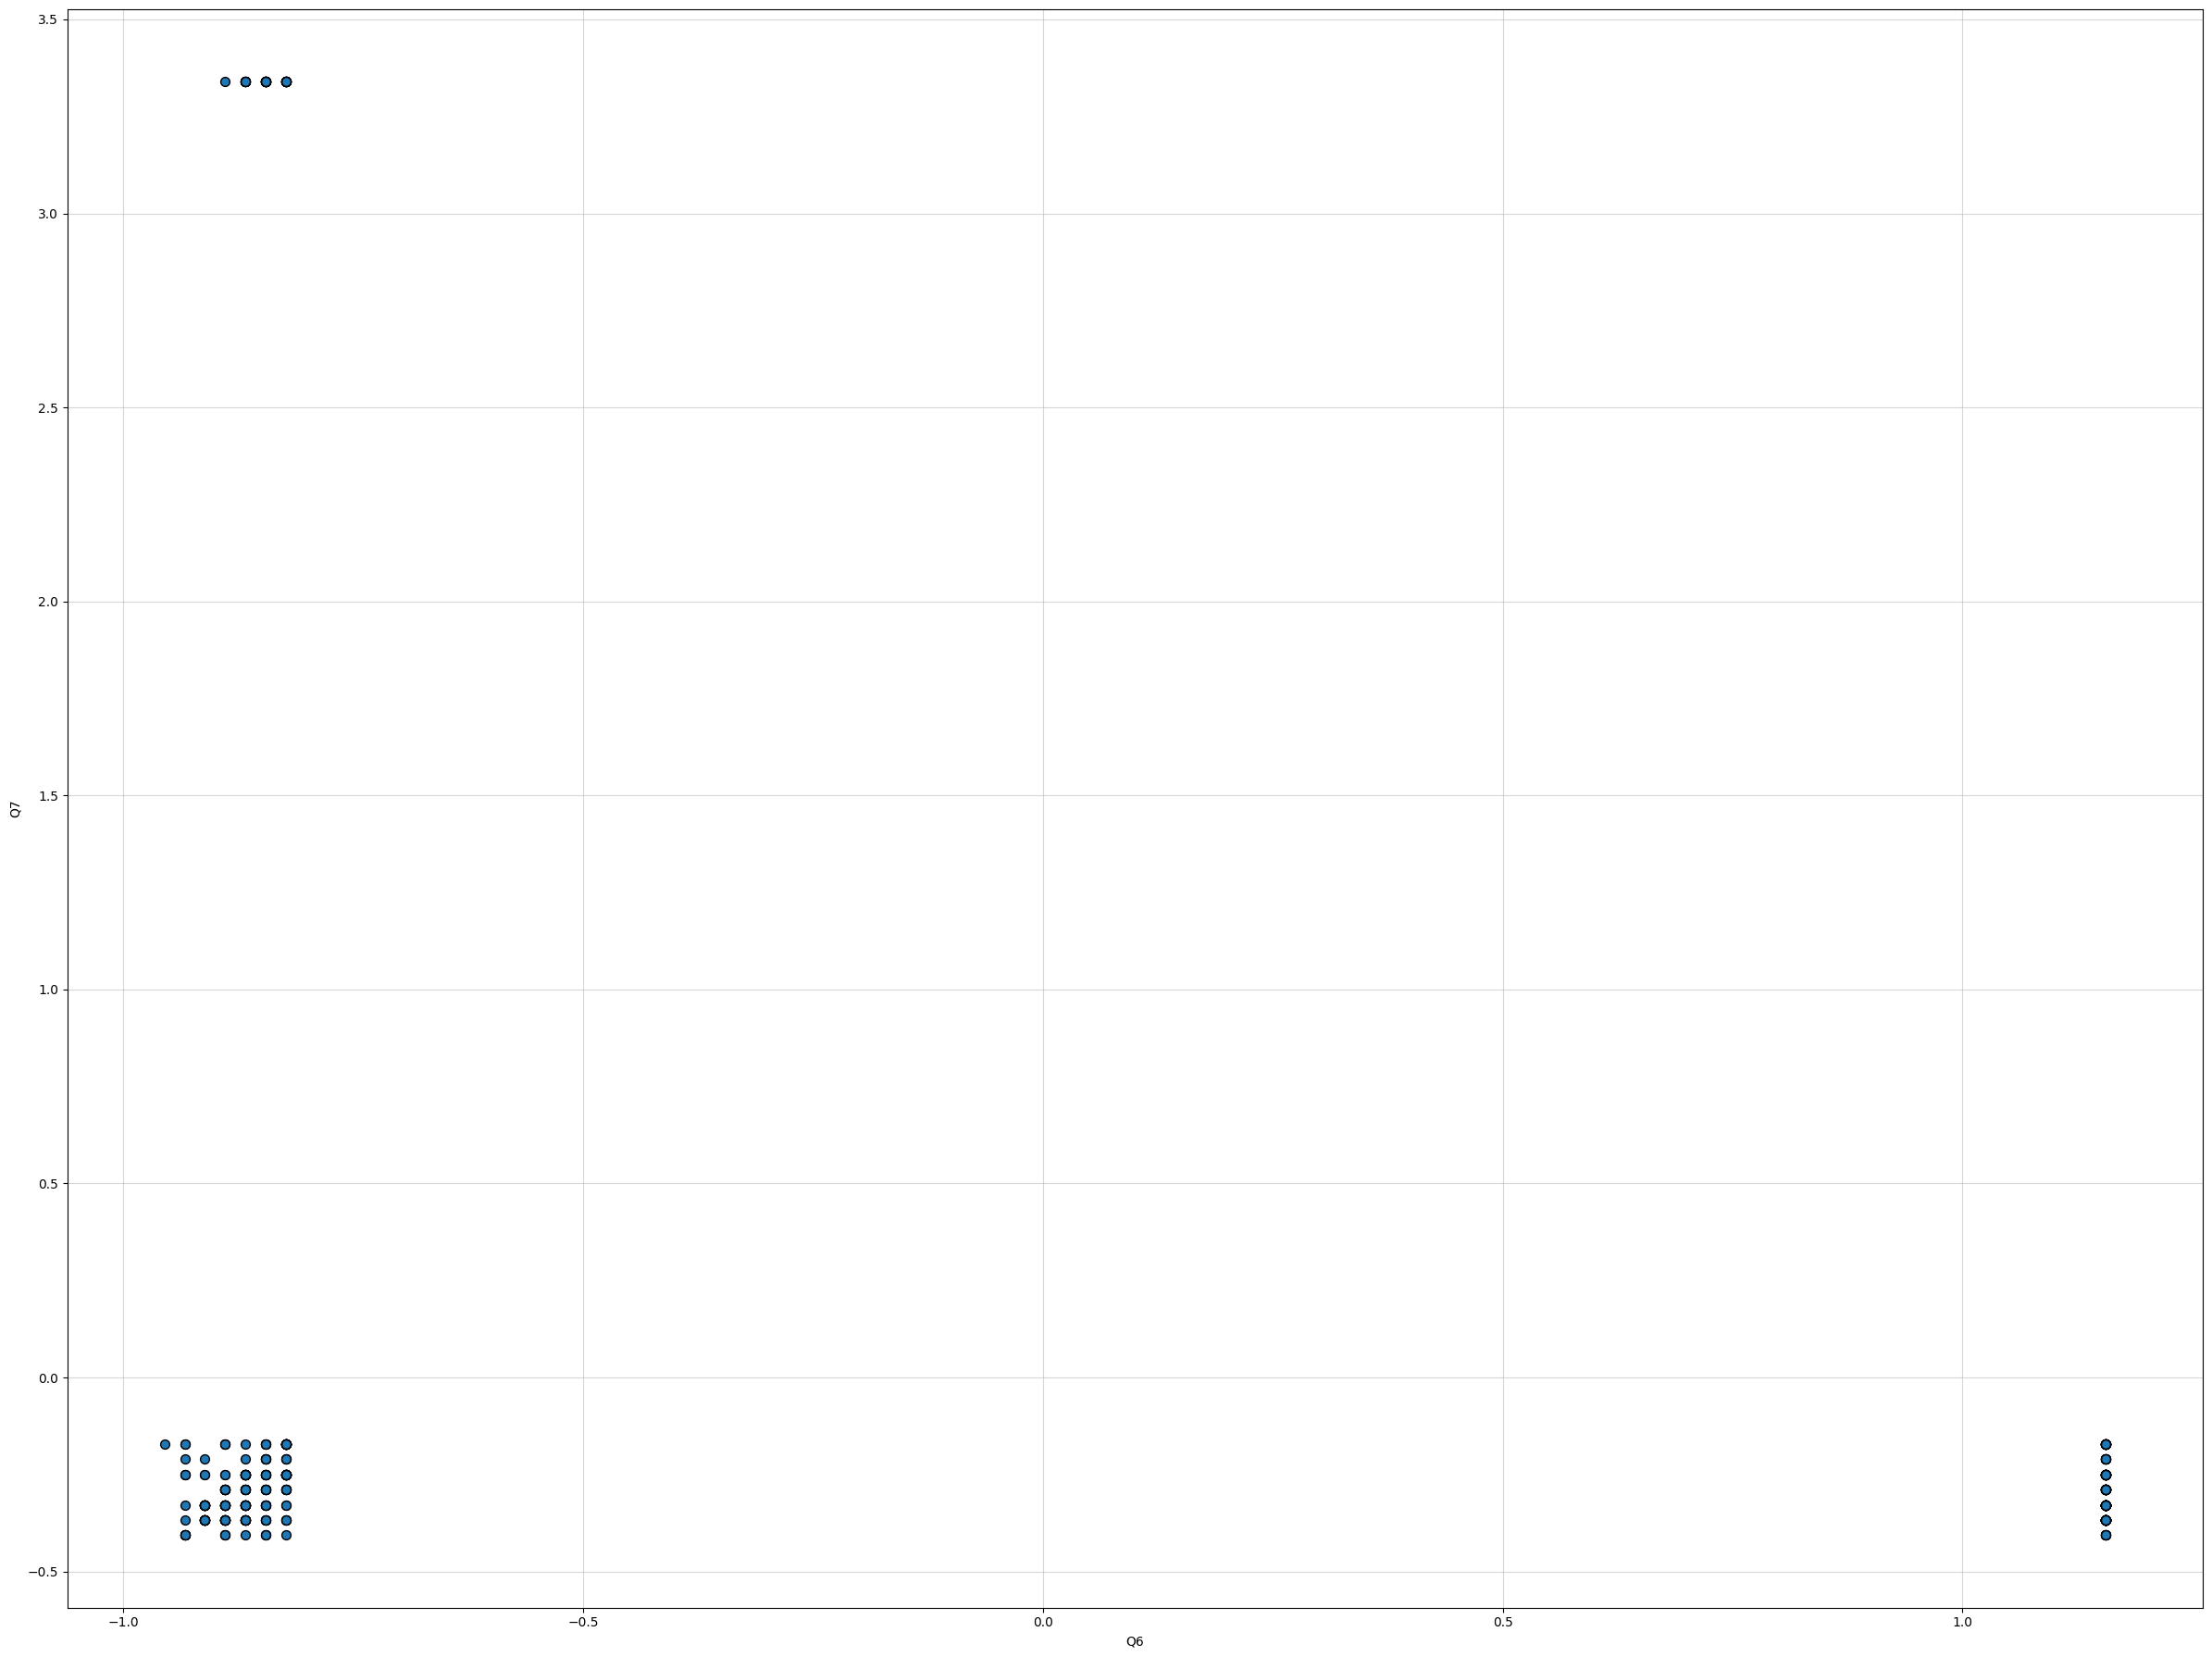

In [14]:
fig, ax = plt.subplots(figsize=(24, 18))

ax.scatter(x_scaler[:, 0], x_scaler[:, 1], s=50, ec="k", zorder=3)
ax.set_xlabel("Q6")
ax.set_ylabel("Q7")

ax.grid(alpha=.5)

plt.tight_layout()
plt.show()

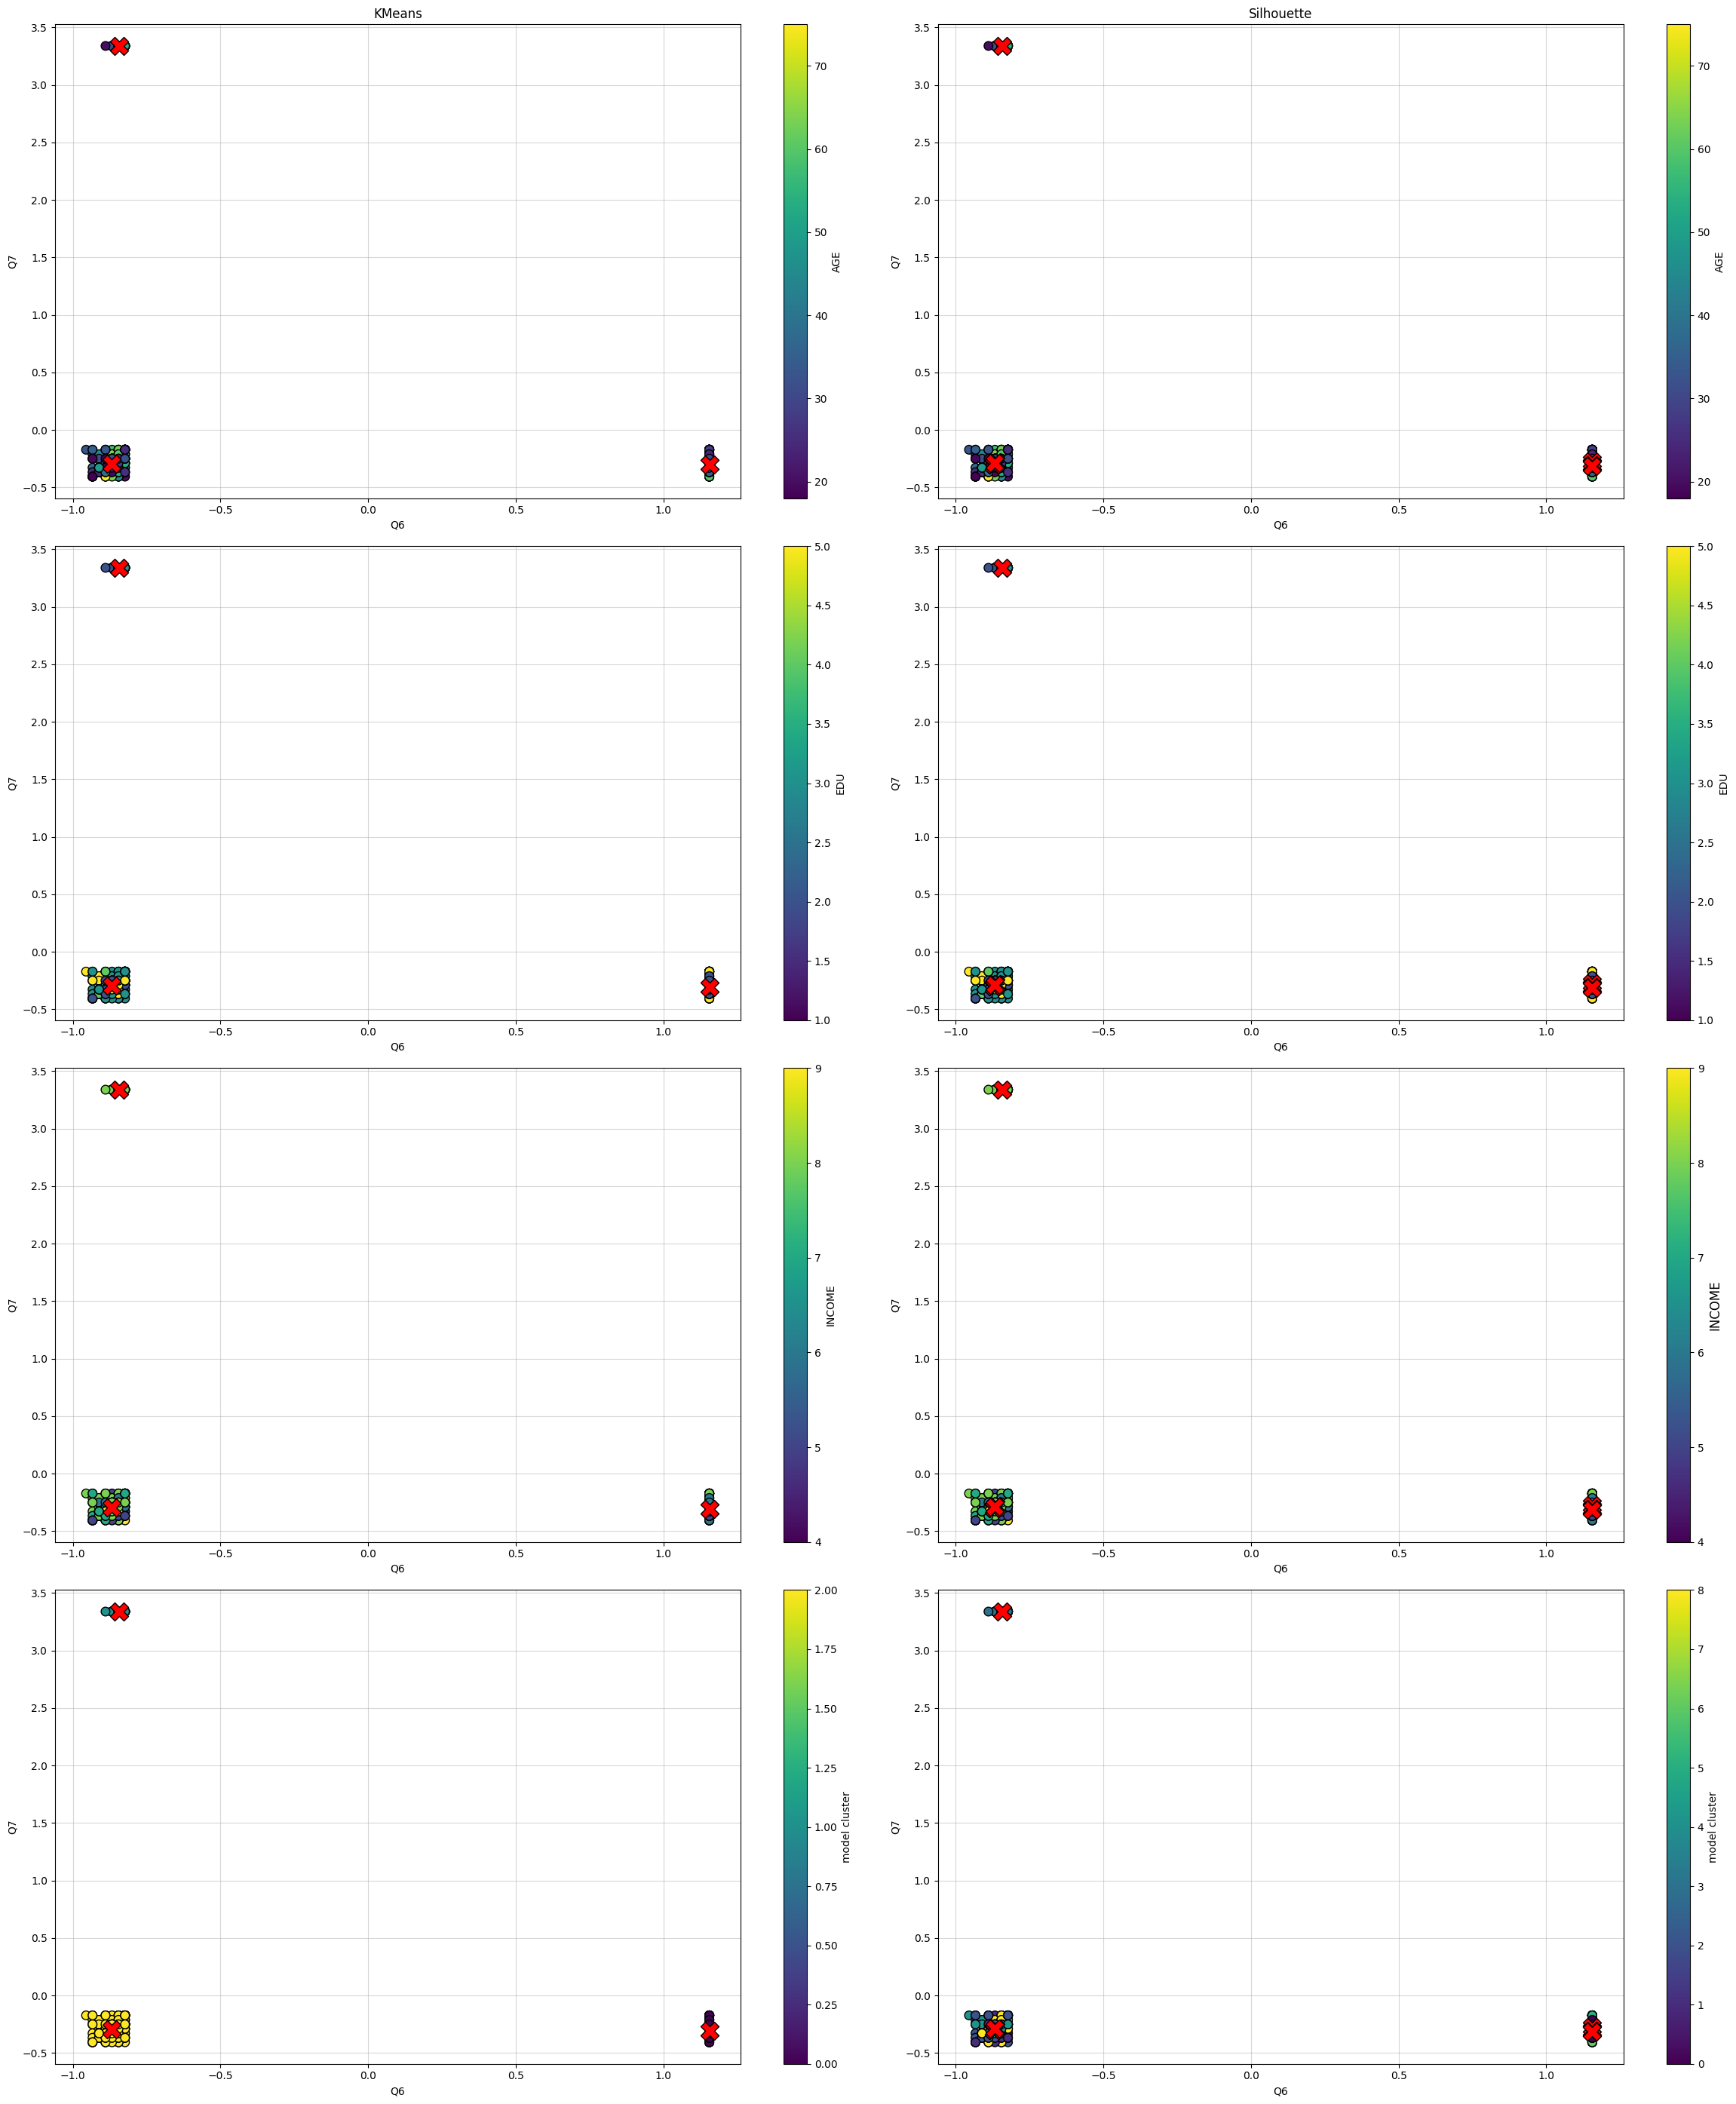

In [15]:
model_KMeans = KMeans(best_k_Kmeans, random_state=42)
model_KMeans.fit(x_scaler)

model_silhouette = KMeans(best_k_silhouette, random_state=42)
model_silhouette.fit(x_scaler)

fig, ax = plt.subplots(4, 2, figsize=(24, 28))

sc1 = ax[0][0].scatter(x_scaler[:, 0], x_scaler[:, 1], c=x["AGE"], s=70, ec="k", zorder=3)
ax[0][0].scatter(model_KMeans.cluster_centers_[:, 0], model_KMeans.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=300, zorder=3)
ax[0][0].set_xlabel("Q6")
ax[0][0].set_ylabel("Q7")

sc2 = ax[0][1].scatter(x_scaler[:, 0], x_scaler[:, 1], c=x["AGE"], s=70, ec="k", zorder=3)
ax[0][1].scatter(model_silhouette.cluster_centers_[:, 0], model_silhouette.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=300, zorder=3)
ax[0][1].set_xlabel("Q6")
ax[0][1].set_ylabel("Q7")

sc3 = ax[1][0].scatter(x_scaler[:, 0], x_scaler[:, 1], c=x["EDU"], s=70, ec="k", zorder=3)
ax[1][0].scatter(model_KMeans.cluster_centers_[:, 0], model_KMeans.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=300, zorder=3)
ax[1][0].set_xlabel("Q6")
ax[1][0].set_ylabel("Q7")

sc4 = ax[1][1].scatter(x_scaler[:, 0], x_scaler[:, 1], c=x["EDU"], s=70, ec="k", zorder=3)
ax[1][1].scatter(model_silhouette.cluster_centers_[:, 0], model_silhouette.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=300, zorder=3)
ax[1][1].set_xlabel("Q6")
ax[1][1].set_ylabel("Q7")

sc5 = ax[2][0].scatter(x_scaler[:, 0], x_scaler[:, 1], c=x["INCOME"], s=70, ec="k", zorder=3)
ax[2][0].scatter(model_KMeans.cluster_centers_[:, 0], model_KMeans.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=300, zorder=3)
ax[2][0].set_xlabel("Q6")
ax[2][0].set_ylabel("Q7")

sc6 = ax[2][1].scatter(x_scaler[:, 0], x_scaler[:, 1], c=x["INCOME"], s=70, ec="k", zorder=3)
ax[2][1].scatter(model_silhouette.cluster_centers_[:, 0], model_silhouette.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=300, zorder=3)
ax[2][1].set_xlabel("Q6")
ax[2][1].set_ylabel("Q7")

sc7 = ax[3][0].scatter(x_scaler[:, 0], x_scaler[:, 1], c=model_KMeans.labels_, s=70, ec="k", zorder=3)
ax[3][0].scatter(model_KMeans.cluster_centers_[:, 0], model_KMeans.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=300, zorder=3)
ax[3][0].set_xlabel("Q6")
ax[3][0].set_ylabel("Q7")

sc8 = ax[3][1].scatter(x_scaler[:, 0], x_scaler[:, 1], c=model_silhouette.labels_, s=70, ec="k", zorder=3)
ax[3][1].scatter(model_silhouette.cluster_centers_[:, 0], model_silhouette.cluster_centers_[:, 1], c="r", marker="X", ec="k", s=300, zorder=3)
ax[3][1].set_xlabel("Q6")
ax[3][1].set_ylabel("Q7")

cbar1 = plt.colorbar(sc1, ax=ax[0][0])
cbar1.set_label("AGE")

cbar2 = plt.colorbar(sc2, ax=ax[0][1])
cbar2.set_label("AGE")

cbar3 = plt.colorbar(sc3, ax=ax[1][0])
cbar3.set_label("EDU")

cbar4 = plt.colorbar(sc4, ax=ax[1][1])
cbar4.set_label("EDU")

cbar5 = plt.colorbar(sc5, ax=ax[2][0])
cbar5.set_label("INCOME")

cbar6 = plt.colorbar(sc6, ax=ax[2][1])
cbar6.set_label("INCOME", fontsize=12)

cbar7 = plt.colorbar(sc7, ax=ax[3][0])
cbar7.set_label("model cluster")

cbar8 = plt.colorbar(sc8, ax=ax[3][1])
cbar8.set_label("model cluster")

ax[0][0].grid(alpha=.5)
ax[0][1].grid(alpha=.5)
ax[1][0].grid(alpha=.5)
ax[1][1].grid(alpha=.5)
ax[2][0].grid(alpha=.5)
ax[2][1].grid(alpha=.5)
ax[3][0].grid(alpha=.5)
ax[3][1].grid(alpha=.5)

ax[0][0].set_title("KMeans")
ax[0][1].set_title("Silhouette")

plt.tight_layout()
plt.show()

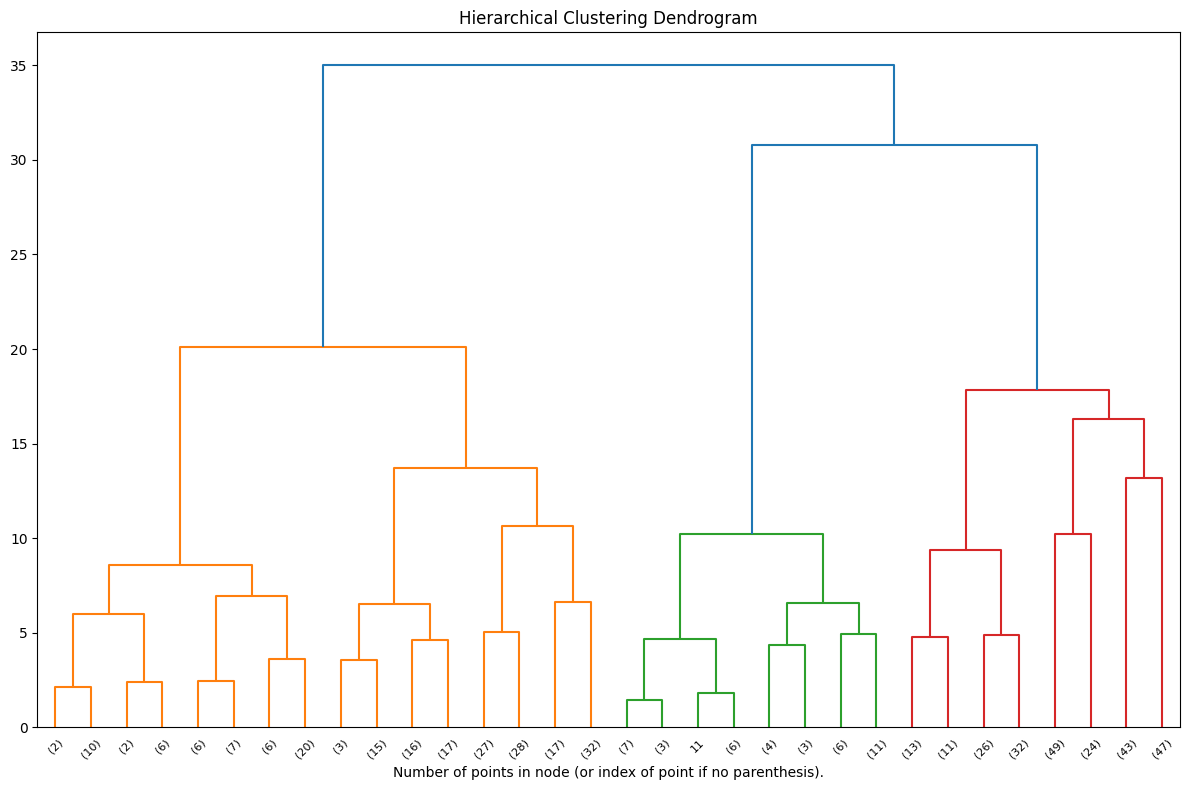

In [16]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.cluster.hierarchy import dendrogram

from sklearn.cluster import AgglomerativeClustering


def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack(
        [model.children_, model.distances_, counts]
    ).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)


# setting distance_threshold=0 ensures we compute the full tree.
model = AgglomerativeClustering(distance_threshold=0, n_clusters=None)

model.fit(x_scaler)

plt.figure(figsize=(12, 8))

plt.title("Hierarchical Clustering Dendrogram")
# plot the top three levels of the dendrogram
plot_dendrogram(model, truncate_mode="level", p=4)

plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.tight_layout()
plt.show()